In [14]:
import anndata as ad
import h5py
import scvelo as scv
import warnings
import matplotlib.pyplot as plt


In [5]:
scv.settings.verbosity = 3  
scv.settings.presenter_view = True 
scv.set_figure_params('scvelo') 
scv.settings.figdir = "/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/figures/"
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [6]:
adata = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/raw/m5_adata_egfp.h5ad")
adata_subset = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/processed/m3454_adata_subset_again_again_(12,34)_(0.5,1)_8_3_25.h5ad")

In [7]:
glasbey_clean_24 = [
    "#E41A1C",  # Red
    "#377EB8",  # Blue
    "#4DAF4A",  # Green
    "#984EA3",  # Purple
    "#FF7F00",  # Orange
    "#FFFF33",  # Yellow
    "#A65628",  # Brown
    "#F781BF",  # Pink
    "#999999",  # Gray
    "#66C2A5",  # Teal
    "#FC8D62",  # Coral
    "#8DA0CB",  # Muted blue
    "#E78AC3",  # Light pink
    "#A6D854",  # Lime
    "#FFD92F",  # Yellow-orange
    "#E5C494",  # Tan
    "#B3B3B3",  # Light gray
    "#1B9E77",  # Deep teal
    "#D95F02",  # Burnt orange
    "#7570B3",  # Muted violet
    "#E7298A",  # Vivid pink
    "#66A61E",  # Olive green
    "#E6AB02",  # Goldenrod
    "#A6761D"   # Rich brown
]

In [8]:
adata_subset

AnnData object with n_obs × n_vars = 1578 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [9]:
adata_raw = adata.copy() 
adata_raw = adata_raw[adata_subset.obs_names, :].copy()
adata_raw = adata_raw[:, adata_subset.var_names].copy()
adata_raw.obsm["X_umap"] = adata_subset.obsm["X_umap"]
adata_raw.obs["leiden"]  = adata_subset.obs["leiden"]

In [10]:
adata_velocity=adata_raw.copy()

In [11]:
adata_velocity

AnnData object with n_obs × n_vars = 1578 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

saving figure to file /blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/figures/scvelo_minus345_velocity_8_6_2025.svg


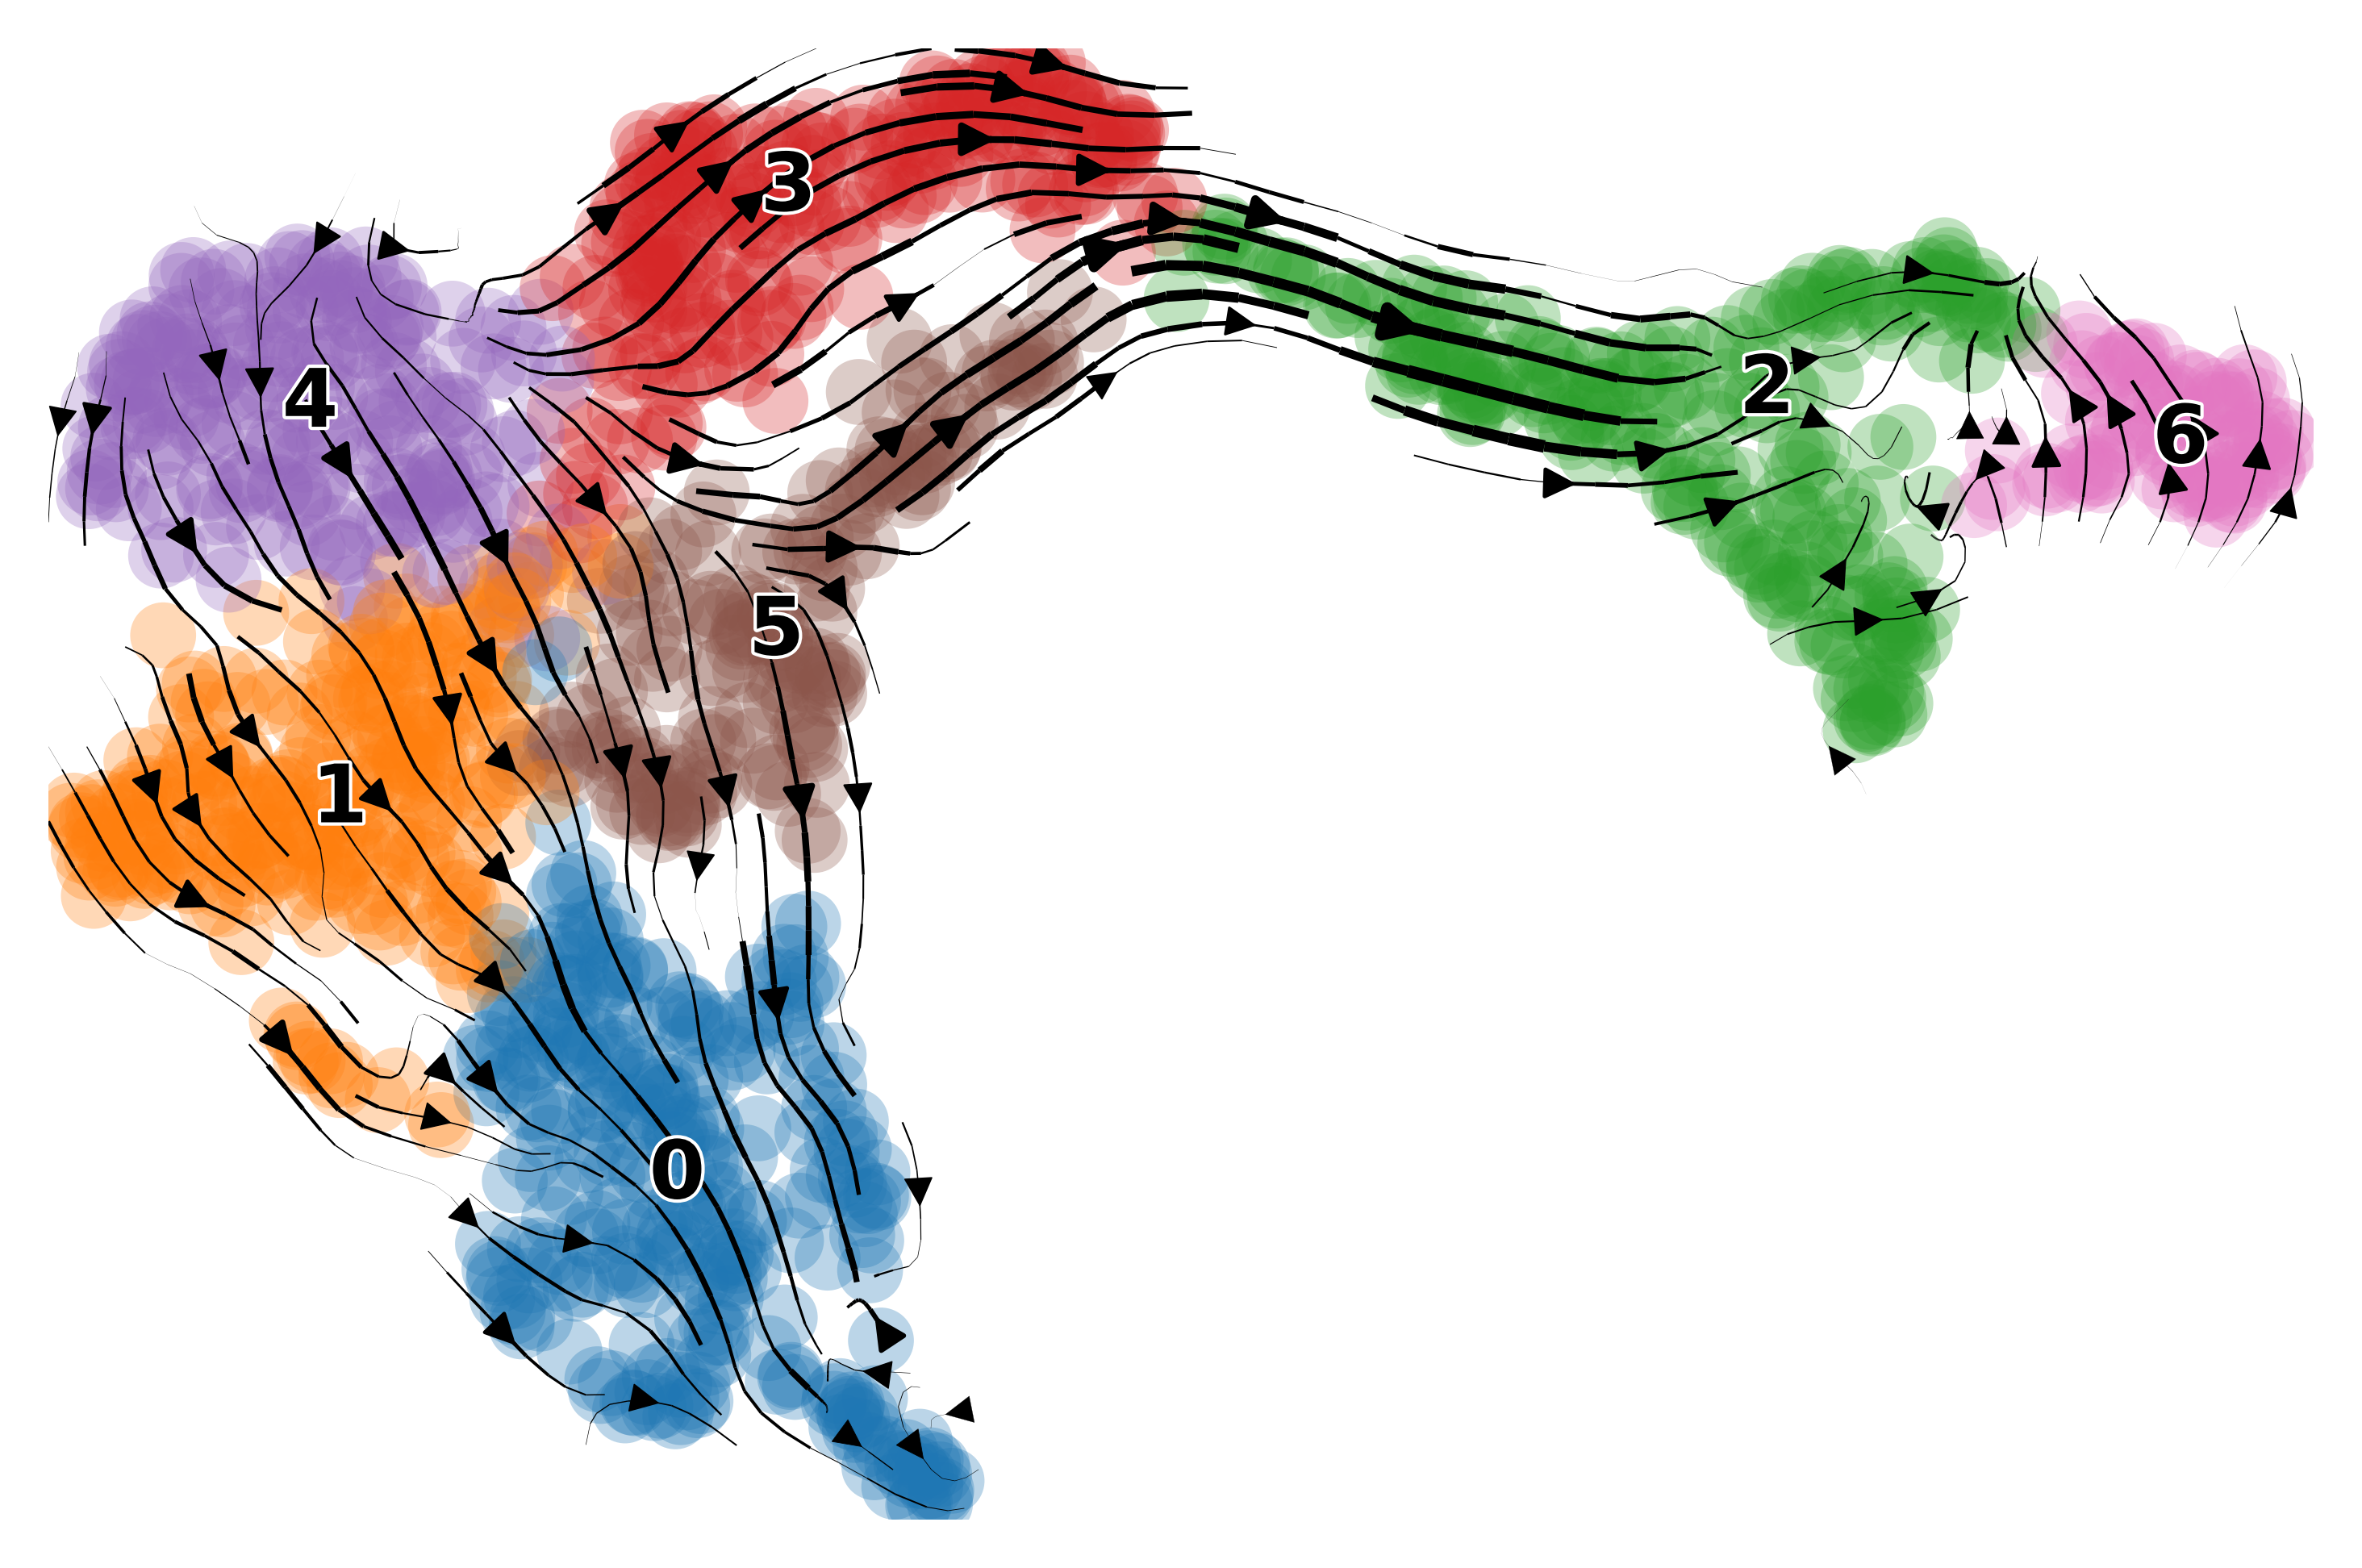

In [17]:
scv.pl.velocity_embedding_stream(
    adata_velocity,
    basis="umap",
    dpi=300,
    color="leiden",
    title="",
    frameon=False,  # helps prevent clipping
    save="minus345_velocity_8_6_2025.svg"
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
scv.pl.velocity_embedding_grid(
    adata_velocity,
    basis="umap",
    color="leiden",
    title="",
    ax=ax,
    show=False,
    arrow_size=117,
)

# Choose ONE of these saves:

# 1) No cropping (exact figure size)
#fig.savefig("minus345_velocity_8_6_2025_thick.svg", dpi=300)


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/squa

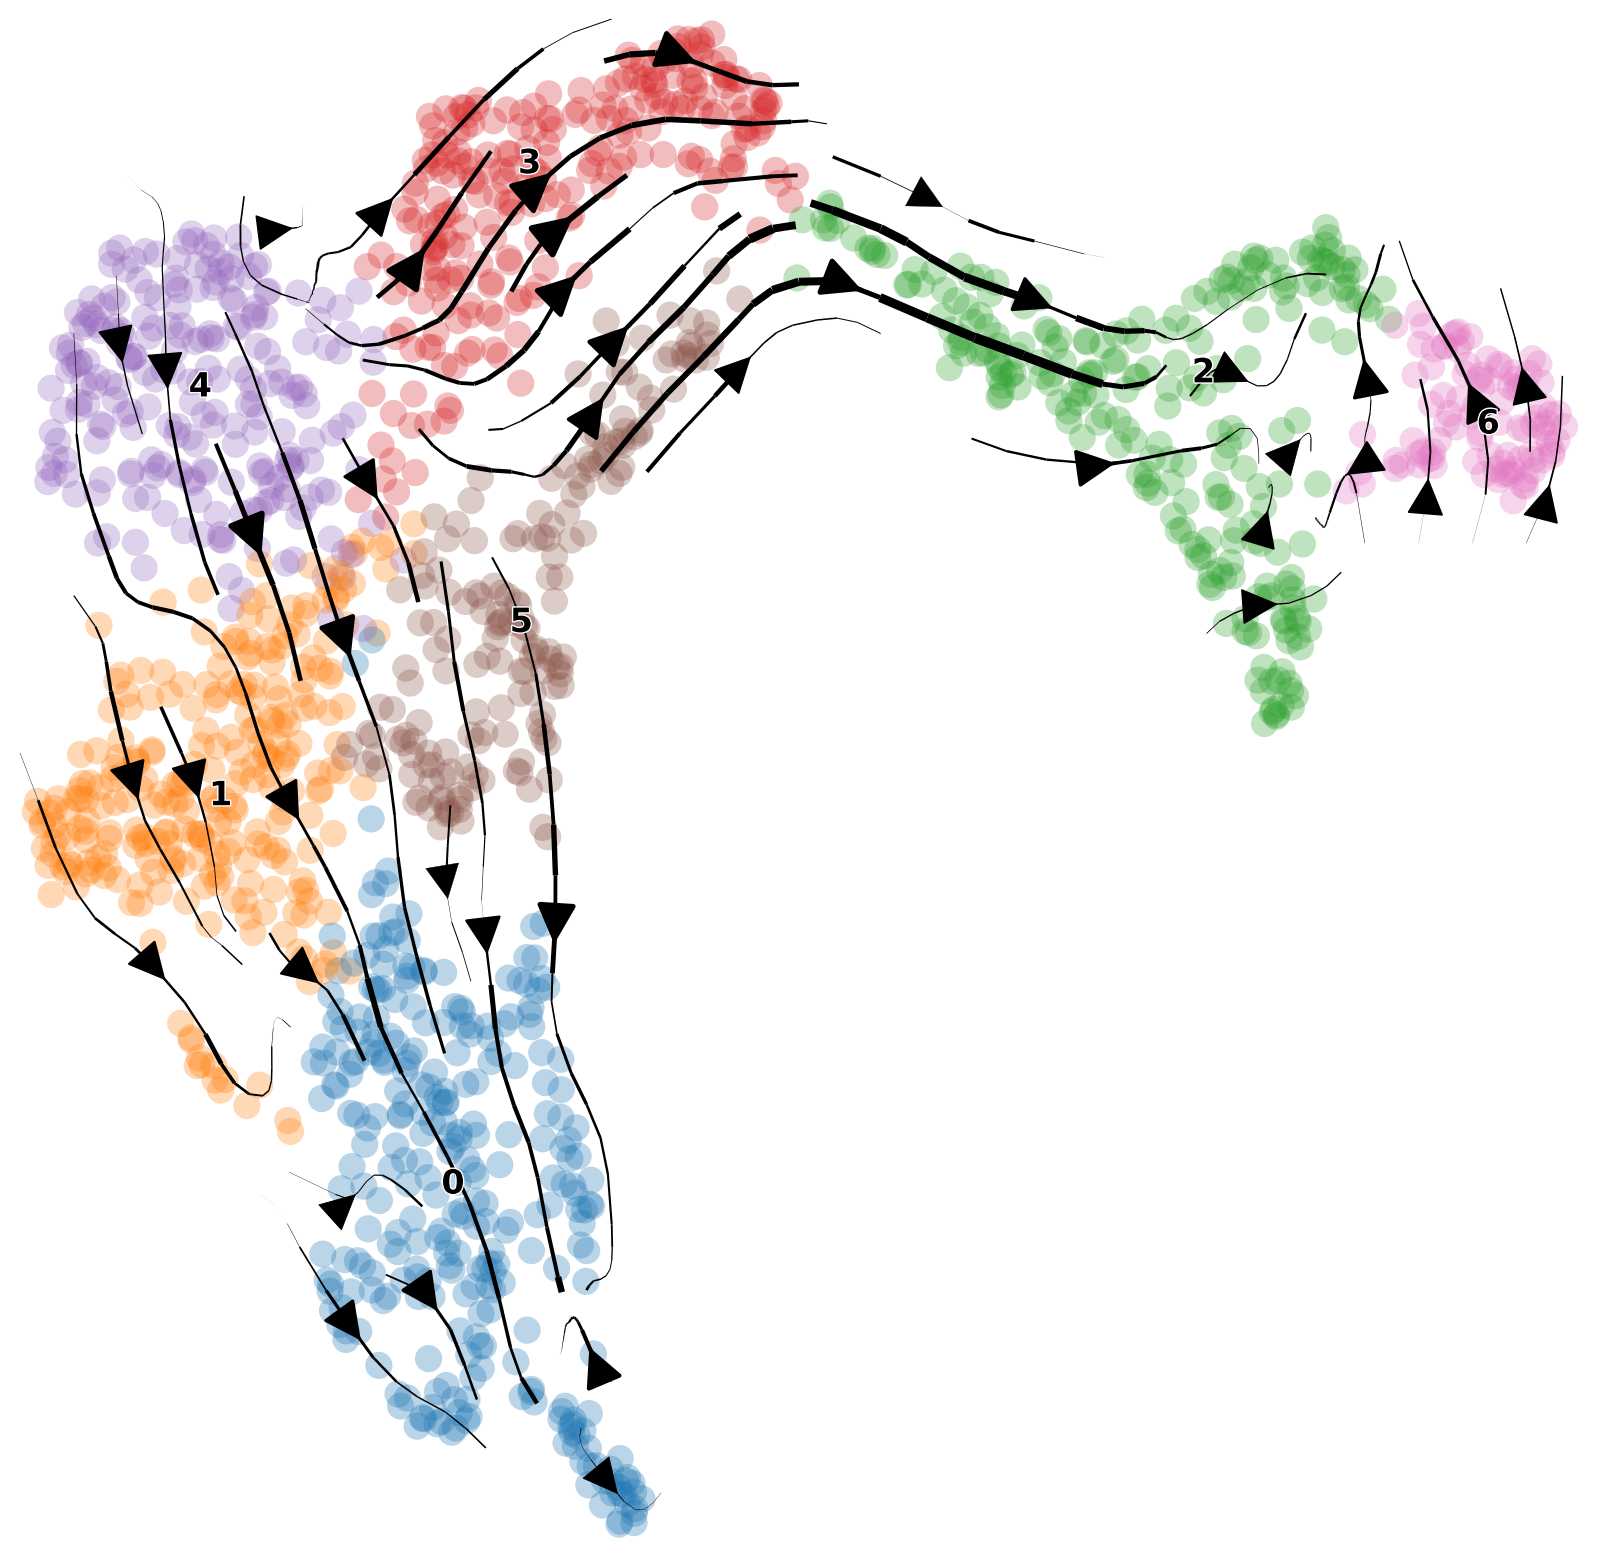

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))
scv.pl.velocity_embedding_stream(
    adata_velocity,
    basis="umap",
    color="leiden",
    title="",
    density=1,
    ax=ax,
    show=False,
    arrow_size=3,
    linewidth=2
)

# Choose ONE of these saves:

# 1) No cropping (exact figure size)
fig.savefig("minus345_velocity_8_6_2025_thick.svg", dpi=300)


Filtered out 958 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.


/scratch/local/9688662/ipykernel_3630693/572025048.py:9: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_velocity, n_pcs=12, n_neighbors=34)
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:00:09) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/128 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:05) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/squa

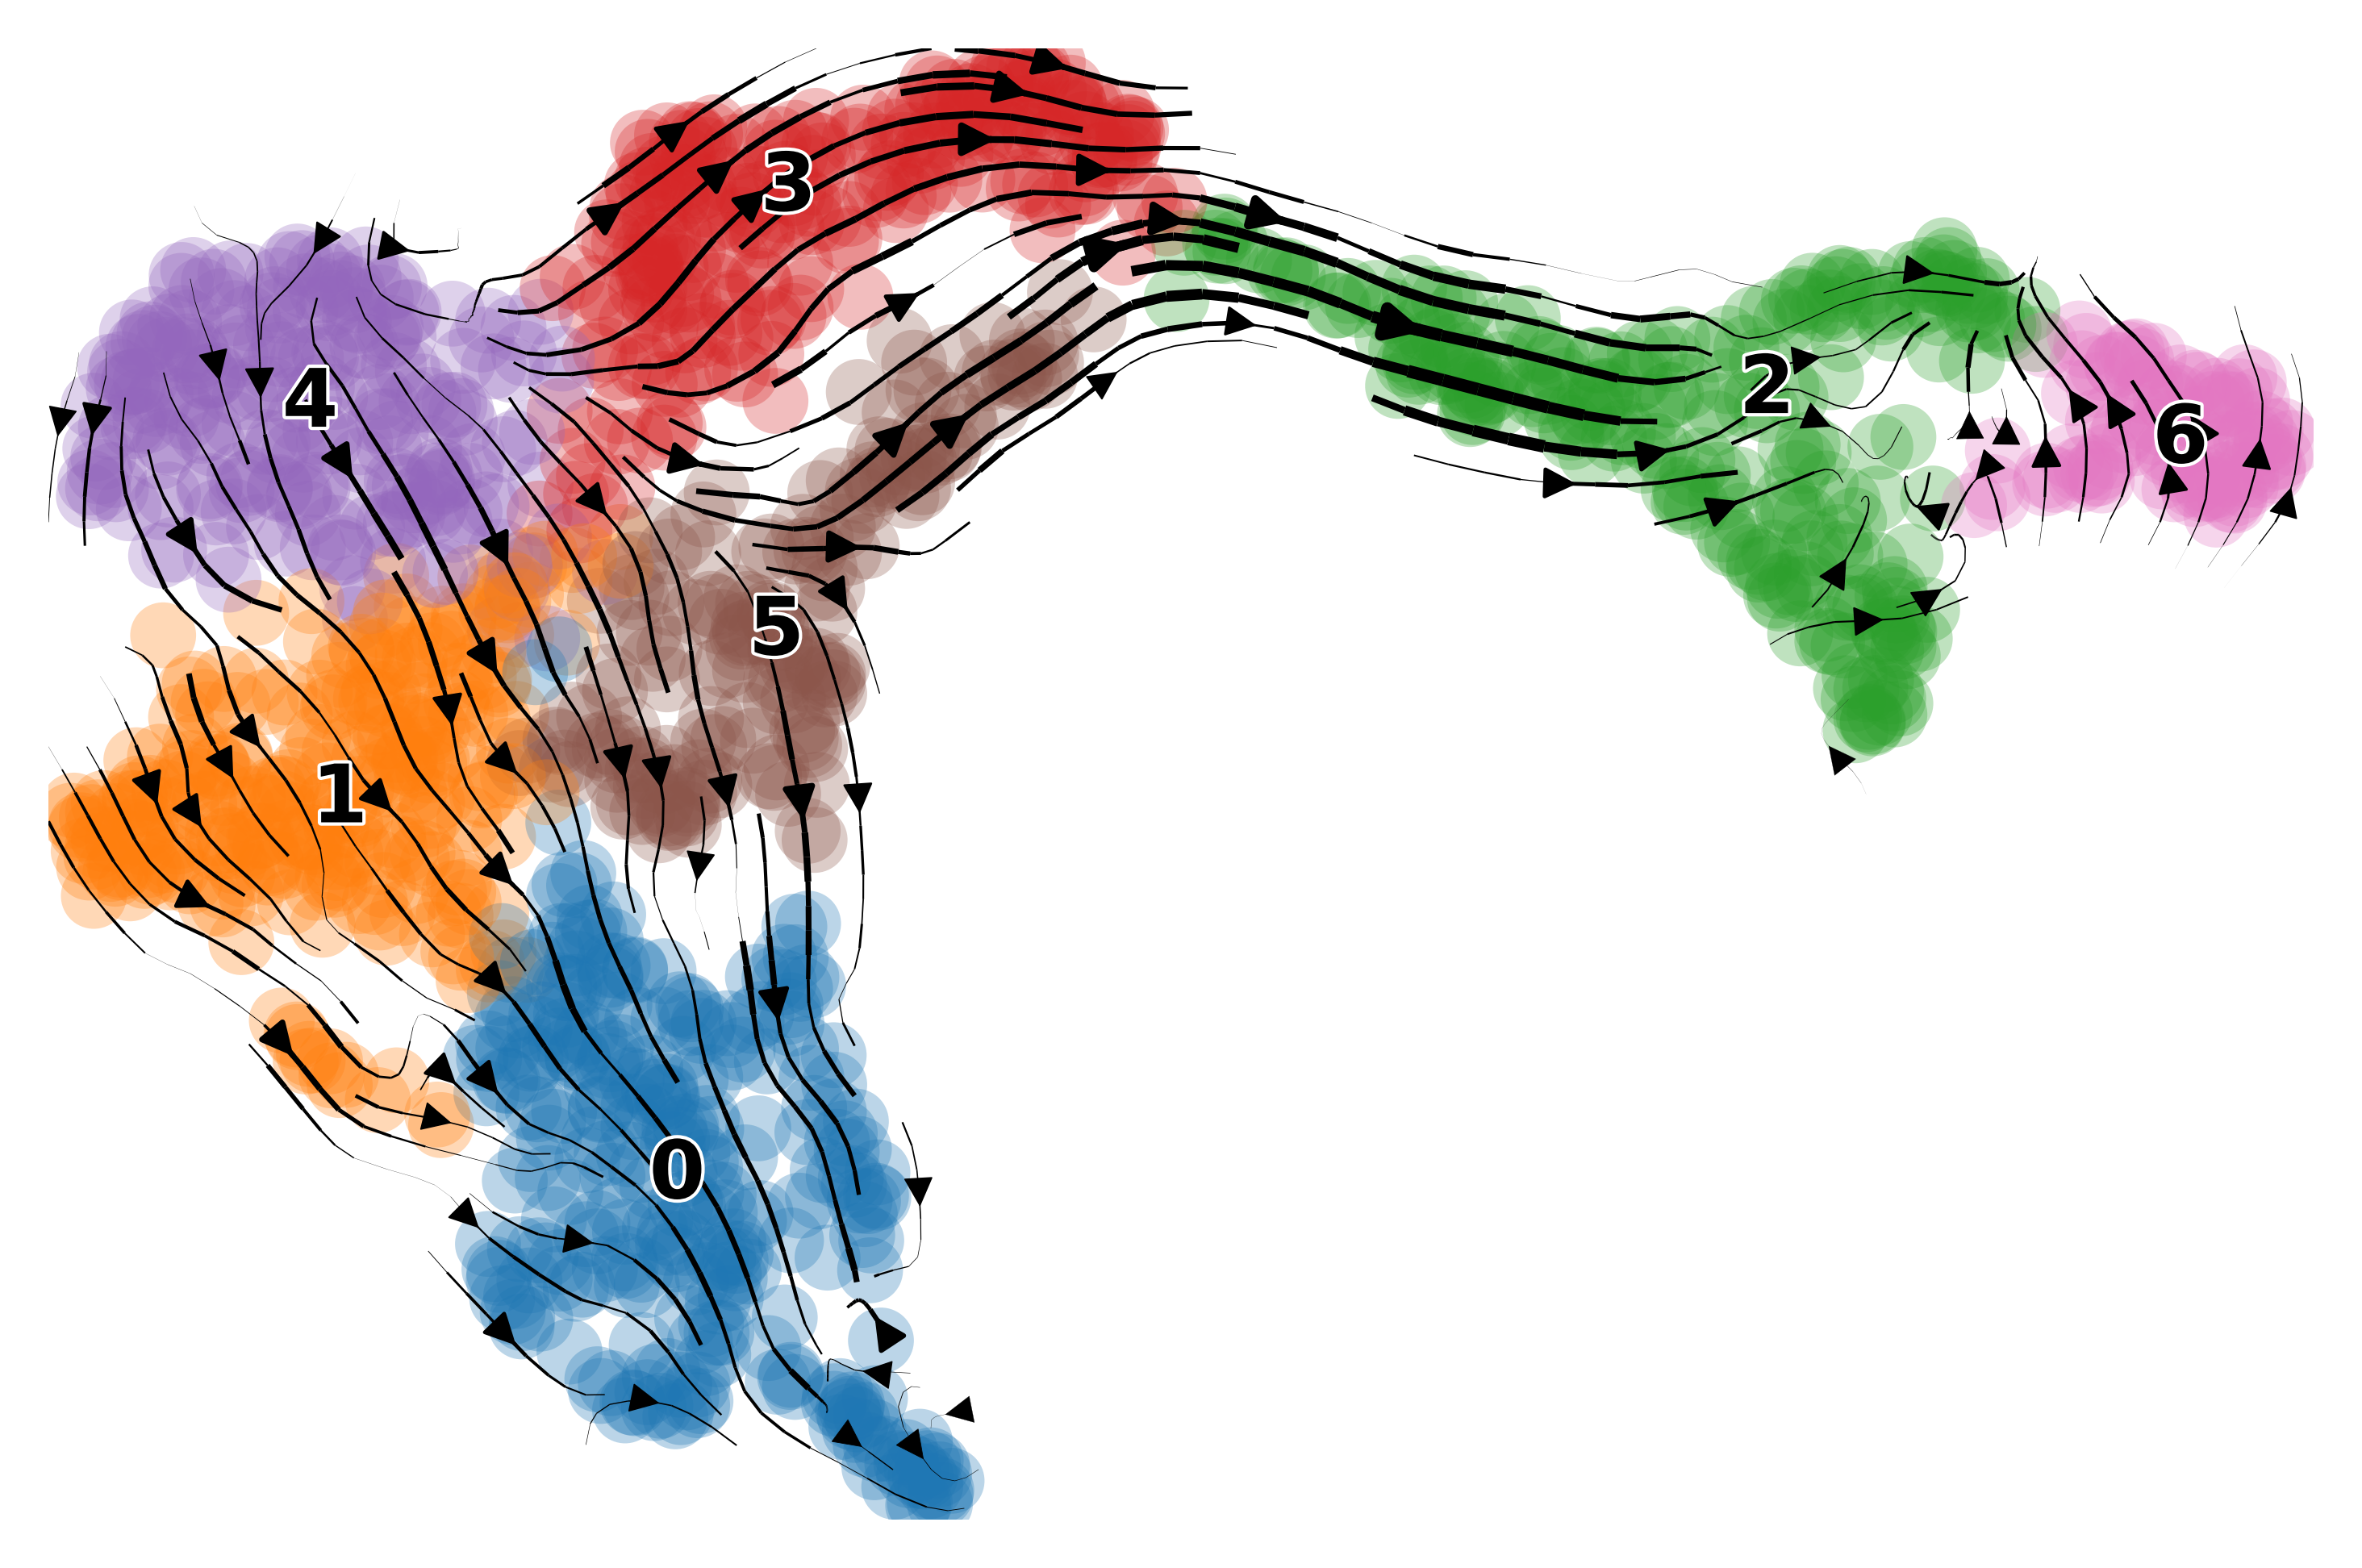

In [12]:
adata_velocity=adata_raw.copy()
scv.pp.filter_and_normalize(
    adata_velocity,
    min_counts=20,
    min_cells=5,
    n_top_genes=None, 
    log=False
)
scv.pp.moments(adata_velocity, n_pcs=12, n_neighbors=34)
#scv.tl.recover_dynamics(adata_velocity, n_jobs=8)
scv.tl.velocity(adata_velocity, mode="stochastic", n_jobs=8)
scv.tl.velocity_graph(adata_velocity, n_jobs=8)
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=300,color="leiden", title="",
                                 #save=f"minus345_velocity_8_6_2025.svg"
                                )

In [ ]:
adata_velocity = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/adata_subset_velocity_final_1.h5ad")
#adata_velocity = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/adata_velocity.h5ad")

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/squa

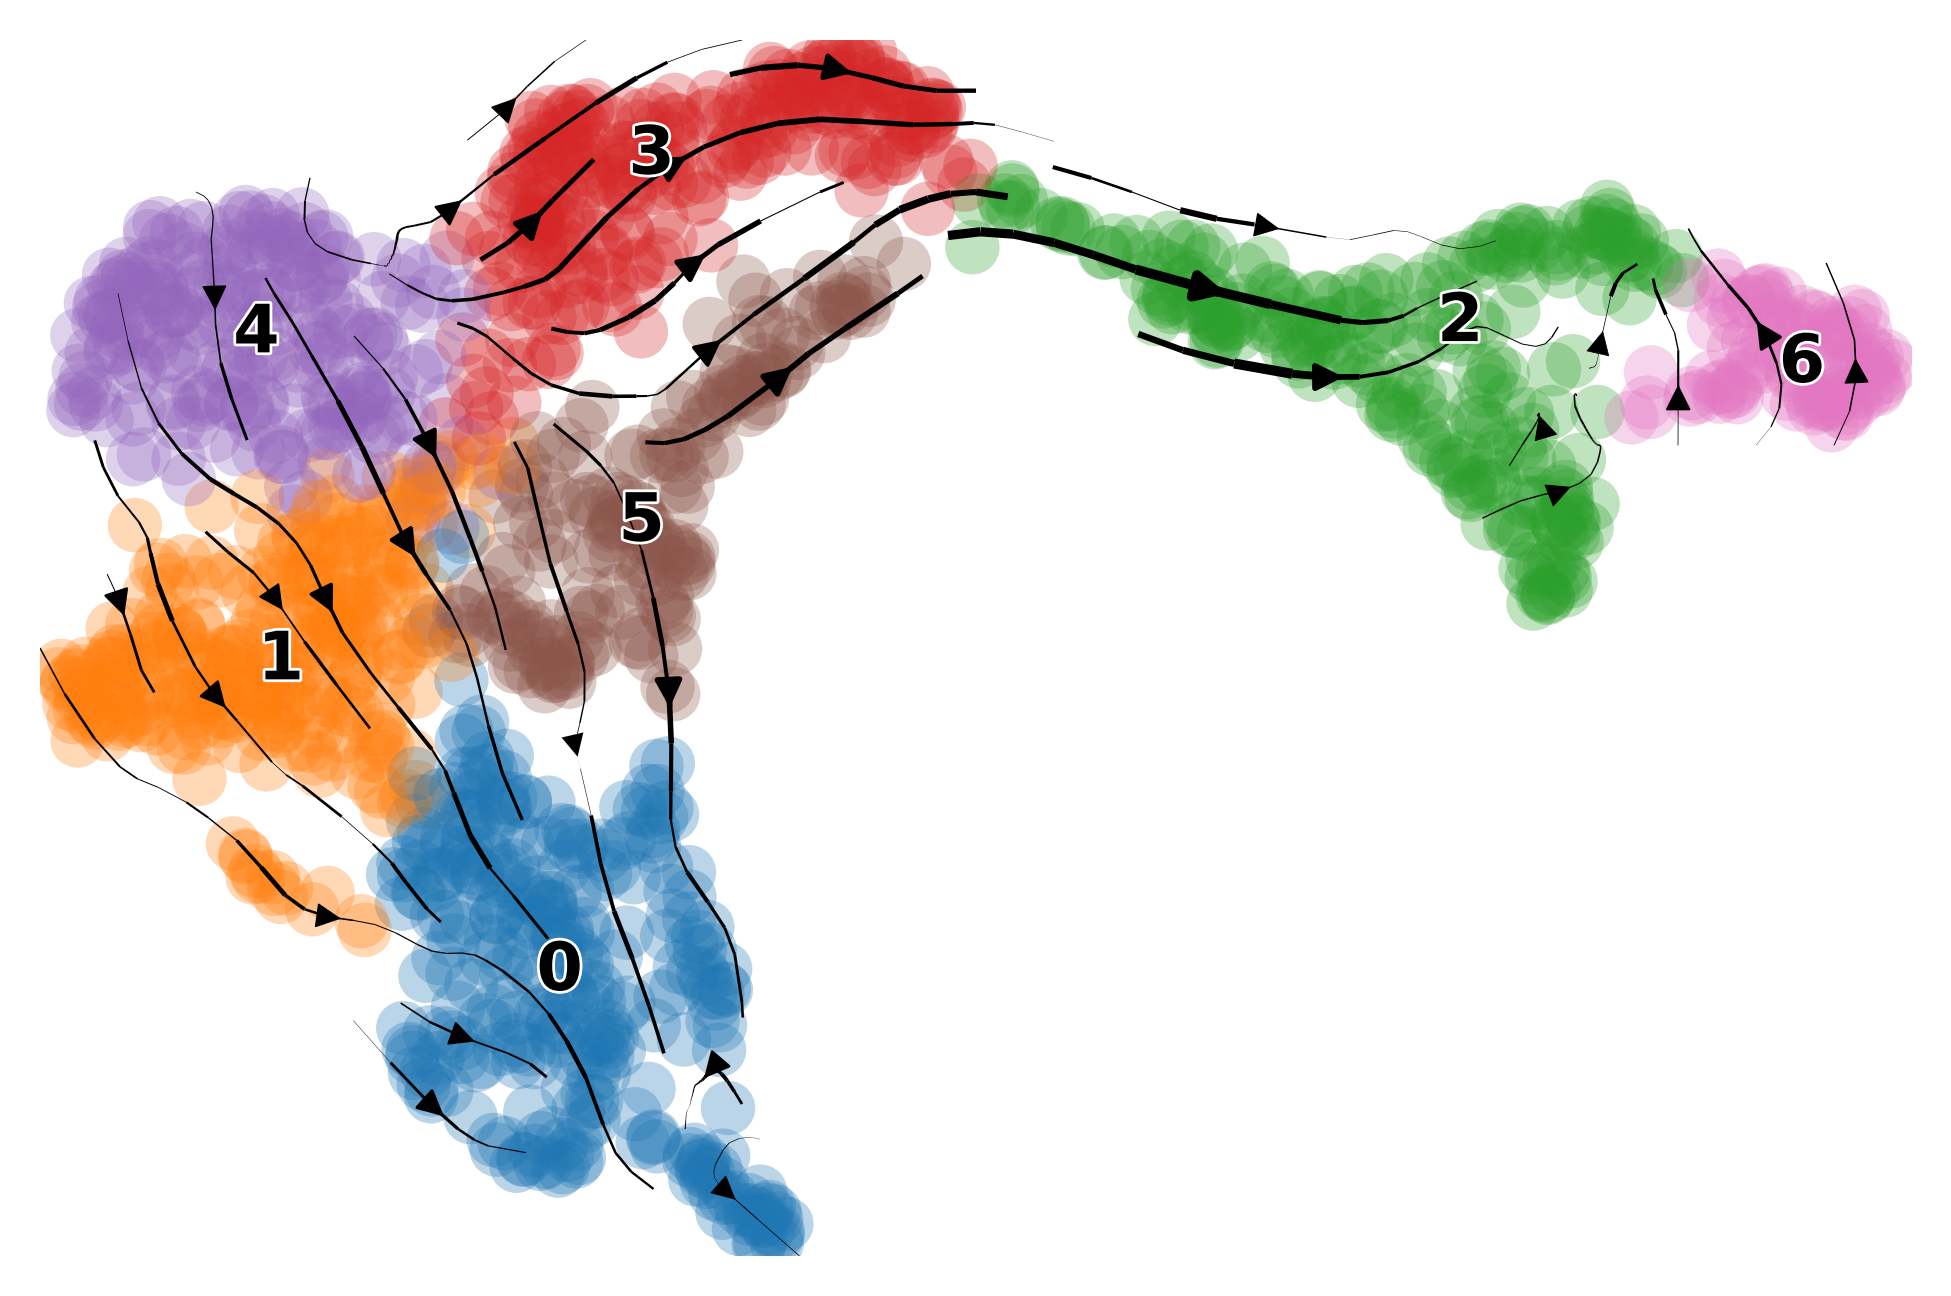

In [12]:
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=200,color="leiden", title="",density=.85
                                 #save="plus345_2_subset_velocity_stream_grey.svg",
                                )